# Engenharia de Features (Feature Engineering)


## Configuração Inicial (Setup)


In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

TARGET = 'arrival_count'
TS_ID = 'series_id'
FREQ = 'ME'
SEASONAL_PERIOD = 12

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)

### Funções Auxiliares do Livro

A maioria dos geradores de features abaixo utiliza funções auxiliares do repositório complementar de:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2ª ed. (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), Licença MIT

| Função Auxiliar | Arquivo fonte | Finalidade |
|---|---|---|
| `add_lags` | `src/features/lag.py` | Lags com shift individual para multi-série |
| `add_rolling_window_features` | `src/features/rolling_window.py` | Estatísticas em janela móvel (média, desvio padrão, min, max) |
| `add_seasonal_rolling_window_features` | `src/features/rolling_window.py` | Estatísticas móveis sazonais defasadas |
| `add_ewma` | `src/features/ewma.py` | Média móvel exponencialmente ponderada |
| `add_calendar_features` | `src/features/calendar.py` | Features de calendário a partir do índice de data |
| `add_elapsed_time` | `src/features/time.py` | Contador linear de tempo normalizado |
| `add_fourier_terms` | `src/features/fourier.py` | Pares de seno/cosseno para sazonalidade periódica |


In [2]:
# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.feature_engineering.autoregressive_features import (  # noqa: E402
    add_ewma,
    add_lags,
    add_rolling_features,
    add_seasonal_rolling_features,
)
from src.feature_engineering.temporal_features import (  # noqa: E402
    add_fourier_features,
    add_temporal_features,
)

## Etapa 1 — Modelagem da Série como Regressão Supervisionada

- Os totais mensais são gerados a partir de `train_ptbr.parquet` e `val_ptbr.parquet`, a mesma agregação dos notebooks anteriores.
- O conjunto de teste (`test_ptbr.parquet`) nunca é lido aqui; o horizonte de validação de 12 meses é a única janela futura considerada.


In [3]:
def load_monthly(file_name, split):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    monthly = raw.set_index('date')[[TARGET]].resample(FREQ).sum()
    monthly['split'] = split
    return monthly


monthly = pd.concat([
    load_monthly('train_ptbr.parquet', 'train'),
    load_monthly('val_ptbr.parquet', 'val'),
]).reset_index()
monthly[TS_ID] = 'brazil_total'
monthly = monthly[['date', TS_ID, 'split', TARGET]]

# every date of this notebook is derived from the split (notebook 2)
TRAIN_END = monthly.loc[monthly['split'] == 'train', 'date'].max()
VAL_START = monthly.loc[monthly['split'] == 'val', 'date'].min()
HORIZON = int((monthly['split'] == 'val').sum())
assert VAL_START == TRAIN_END + pd.offsets.MonthEnd(1), 'validation must follow train'

for split, part in monthly.groupby('split', sort=False):
    print(
        f'{split:<5}: {part["date"].min():%b %Y} → {part["date"].max():%b %Y} '
        f'({len(part)} months)'
    )
print(f'HORIZON = {HORIZON} months')
display(monthly.tail(15))


train: Jan 1989 → Aug 2024 (428 months)
val  : Sep 2024 → Aug 2025 (12 months)
HORIZON = 12 months


,date,series_id,split,arrival_count
425,2024-06-30,brazil_total,train,332474.0
426,2024-07-31,brazil_total,train,437103.0
427,2024-08-31,brazil_total,train,417940.0
428,2024-09-30,brazil_total,val,445389.0
429,2024-10-31,brazil_total,val,508738.0
430,2024-11-30,brazil_total,val,560732.0
431,2024-12-31,brazil_total,val,806478.0
432,2025-01-31,brazil_total,val,1483669.0
433,2025-02-28,brazil_total,val,1326884.0
434,2025-03-31,brazil_total,val,929096.0


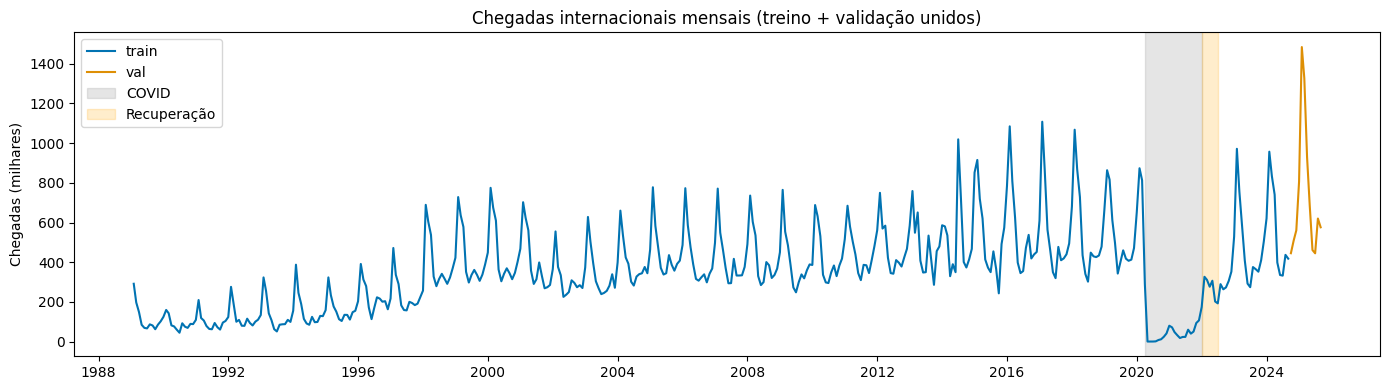

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
for split, part in monthly.groupby('split', sort=False):
    ax.plot(part['date'], part[TARGET] / 1e3, label=split)
ax.axvspan(COVID_START, COVID_END, color='grey', alpha=0.2, label='COVID')
ax.axvspan(
    POST_COVID_START, COVID_RECOVERY_END, color='orange', alpha=0.2, label='Recuperação'
)
ax.set_title('Chegadas internacionais mensais (treino + validação unidos)')
ax.set_ylabel('Chegadas (milhares)')
ax.legend()
plt.tight_layout()
plt.show()

**Ilustração da janela deslizante.** Com uma memória de `M = 3` meses, as linhas da tabela associam os lags do passado ao valor presente.


In [5]:
M = 3
window_example = pd.DataFrame(
    {f'y(t-{k})': monthly[TARGET].shift(k) for k in range(M, 0, -1)}
    | {'y(t) → target': monthly[TARGET]}
).set_index(monthly['date'].dt.strftime('%b %Y'))
window_example.iloc[M : M + 6]

,y(t-3),y(t-2),y(t-1),y(t) → target
date,,,,
Apr 1989,291566.0,197348.0,149001.0,84867.0
May 1989,197348.0,149001.0,84867.0,69293.0
Jun 1989,149001.0,84867.0,69293.0,66838.0
Jul 1989,84867.0,69293.0,66838.0,87054.0
Aug 1989,69293.0,66838.0,87054.0,81535.0
Sep 1989,66838.0,87054.0,81535.0,62629.0


## Etapa 2 — Escolha da Memória: FAC e FACP


Significant PACF lags: {1: 0.81, 2: -0.19, 4: 0.15, 5: 0.2, 7: -0.16, 8: 0.17, 9: 0.36, 10: 0.38, 11: 0.39, 12: 0.44, 13: -0.32, 14: -0.11, 24: 0.2, 25: -0.18, 28: -0.1, 36: 0.13}
ACF at 12 / 24 / 36  : [0.86, 0.76, 0.65]


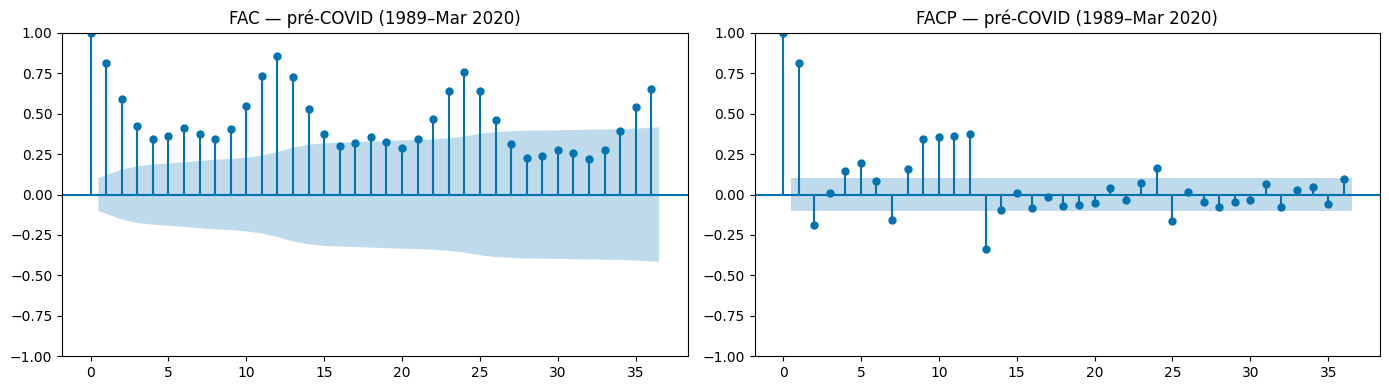

In [6]:
pre_covid = monthly.loc[
    (monthly['split'] == 'train') & (monthly['date'] < COVID_START), TARGET
]
N_LAGS = 36


def significant_lags(values, conf_int):
    half_width = conf_int[:, 1] - values
    return {
        lag: round(float(values[lag]), 2)
        for lag in range(1, len(values))
        if abs(values[lag]) > half_width[lag]
    }


acf_values, acf_ci = acf(pre_covid, nlags=N_LAGS, alpha=0.05)
pacf_values, pacf_ci = pacf(pre_covid, nlags=N_LAGS, alpha=0.05)
print('Significant PACF lags:', significant_lags(pacf_values, pacf_ci))
print('ACF at 12 / 24 / 36  :', [round(float(acf_values[k]), 2) for k in (12, 24, 36)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(pre_covid, lags=N_LAGS, ax=axes[0], title='FAC — pré-COVID (1989–Mar 2020)')
plot_pacf(pre_covid, lags=N_LAGS, ax=axes[1], title='FACP — pré-COVID (1989–Mar 2020)')
plt.tight_layout()
plt.show()

**Interpretação.**


## Etapa 3 — Estratégias de Previsão e Regra de Não-Vazamento (Leakage)

Duas estratégias multi-step são construídas em paralelo:

| Estratégia | Previsão de cada passo futuro | Features derivadas do alvo no conjunto de validação |
|---|---|---|
| **Recursiva** | O modelo de 1 passo à frente é alimentado iterativamente com suas próprias previsões | Mascaradas (`NaN`) — calculadas dinamicamente durante a inferência recursiva |
| **Direta** | 12 modelos independentes, cada um treinado para prever o horizonte *h* diretamente | Completas — dependem apenas de dados observados até a origem |


In [7]:
BASE_LAGS = [1, 2, 12, 13, 24, 36]

STRATEGIES = {
    'recursive': {'min_shift': 1},
    'direct': {'min_shift': HORIZON},
}
for cfg in STRATEGIES.values():
    cfg['lags'] = [lag for lag in BASE_LAGS if lag >= cfg['min_shift']]

ROLLING_WINDOWS = [3, 6, 12]
ROLLING_AGGS = ['mean', 'std', 'min', 'max']
SEASONAL_WINDOWS = [2, 3]  # the same month of the 2 / 3 previous years
SEASONAL_AGGS = ['mean', 'std']
EWMA_SPANS = [3, 6, 12]
FOURIER_TERMS = 3

display(pd.DataFrame(STRATEGIES).T)

# one working table per strategy, filled step by step
features = {name: monthly.copy() for name in STRATEGIES}
feature_groups = {name: {} for name in STRATEGIES}

# around the train/validation boundary: the last 3 train and first 3 validation months
BOUNDARY = slice(TRAIN_END - pd.offsets.MonthEnd(2), VAL_START + pd.offsets.MonthEnd(2))


def show_step(group, columns=None, rows=BOUNDARY):
    """Summarize a step's new features and show them around the train/val boundary."""
    display(
        pd.DataFrame({
            name: {
                'n_features': len(groups[group]),
                'features': ', '.join(groups[group]),
            }
            for name, groups in feature_groups.items()
        }).T
    )
    for name, frame in features.items():
        cols = columns or feature_groups[name][group]
        cols = [c for c in cols if c in frame.columns]
        print(f'{name} — sample around the train/validation boundary')
        display(frame.set_index('date').loc[rows, ['split', TARGET, *cols]])

,min_shift,lags
recursive,1,"[1, 2, 12, 13, 24, 36]"
direct,12,"[12, 13, 24, 36]"


## Etapa 4 — Lags (Defasagens Temporais)


In [8]:
def add_lag_features(df, cfg):
    return add_lags(df, lags=cfg['lags'], column=TARGET, ts_id=TS_ID)


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['lags'] = add_lag_features(features[name], cfg)

show_step('lags')

,n_features,features
recursive,6,"arrival_count_lag_1, arrival_count_lag_2, arri..."
direct,4,"arrival_count_lag_12, arrival_count_lag_13, ar..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_lag_1,arrival_count_lag_2,arrival_count_lag_12,arrival_count_lag_13,arrival_count_lag_24,arrival_count_lag_36
date,,,,,,,,
2024-06-30,train,332474.0,335652.0,398587.0,274302.0,292375.0,192909.0,24070.0
2024-07-31,train,437103.0,332474.0,335652.0,375648.0,274302.0,289581.0,60270.0
2024-08-31,train,417940.0,437103.0,332474.0,365041.0,375648.0,263626.0,40410.0
2024-09-30,val,445389.0,417940.0,437103.0,352355.0,365041.0,273004.0,50675.0
2024-10-31,val,508738.0,445389.0,417940.0,409924.0,352355.0,305644.0,93824.0
2024-11-30,val,560732.0,508738.0,445389.0,504395.0,409924.0,352458.0,107123.0


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_lag_12,arrival_count_lag_13,arrival_count_lag_24,arrival_count_lag_36
date,,,,,,
2024-06-30,train,332474.0,274302.0,292375.0,192909.0,24070.0
2024-07-31,train,437103.0,375648.0,274302.0,289581.0,60270.0
2024-08-31,train,417940.0,365041.0,375648.0,263626.0,40410.0
2024-09-30,val,445389.0,352355.0,365041.0,273004.0,50675.0
2024-10-31,val,508738.0,409924.0,352355.0,305644.0,93824.0
2024-11-30,val,560732.0,504395.0,409924.0,352458.0,107123.0


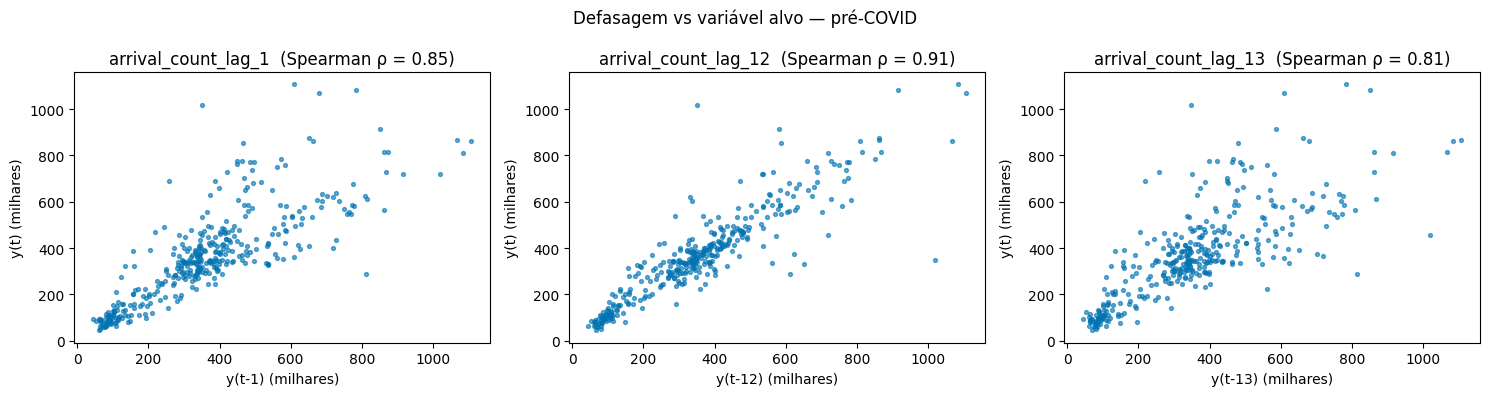

In [9]:
lag_view = features['recursive'].query('date < @COVID_START')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lag in zip(axes, [1, 12, 13]):
    col = f'{TARGET}_lag_{lag}'
    rho = lag_view[[col, TARGET]].corr(method='spearman').iloc[0, 1]
    ax.scatter(lag_view[col] / 1e3, lag_view[TARGET] / 1e3, s=8, alpha=0.6)
    ax.set_title(f'{col}  (Spearman ρ = {rho:.2f})')
    ax.set_xlabel(f'y(t-{lag}) (milhares)')
    ax.set_ylabel('y(t) (milhares)')
fig.suptitle('Defasagem vs variável alvo — pré-COVID')
plt.tight_layout()
plt.show()

## Etapa 5 — Agregações em Janela Móvel


In [10]:
def add_rolling_window_features(df, cfg):
    return add_rolling_features(
        df,
        rolls=ROLLING_WINDOWS,
        column=TARGET,
        agg_funcs=ROLLING_AGGS,
        ts_id=TS_ID,
        n_shift=cfg['min_shift'],
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['rolling'] = add_rolling_window_features(
        features[name], cfg
    )

show_step(
    'rolling',
    columns=[
        f'{TARGET}_rolling_3_mean',
        f'{TARGET}_rolling_12_mean',
        f'{TARGET}_rolling_12_std',
    ],
)

,n_features,features
recursive,12,"arrival_count_rolling_3_mean, arrival_count_ro..."
direct,12,"arrival_count_rolling_3_mean, arrival_count_ro..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_rolling_3_mean,arrival_count_rolling_12_mean,arrival_count_rolling_12_std
date,,,,,
2024-06-30,train,332474.0,491574.000000,513966.750000,221917.074675
2024-07-31,train,437103.0,355571.000000,518814.416667,216781.728474
2024-08-31,train,417940.0,368409.666667,523935.666667,213797.461958
2024-09-30,val,445389.0,395839.000000,528343.916667,210746.999628
2024-10-31,val,508738.0,433477.333333,536096.750000,205325.776332
2024-11-30,val,560732.0,457355.666667,544331.250000,201756.079815


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_rolling_3_mean,arrival_count_rolling_12_mean,arrival_count_rolling_12_std
date,,,,,
2024-06-30,train,332474.0,325158.333333,441096.500000,226897.971684
2024-07-31,train,437103.0,314108.333333,448268.750000,222999.969521
2024-08-31,train,417940.0,338330.333333,456720.000000,217212.857520
2024-09-30,val,445389.0,364348.000000,463332.583333,212263.012164
2024-10-31,val,508738.0,375773.333333,472022.583333,207296.898175
2024-11-30,val,560732.0,422224.666667,484684.000000,203943.082530


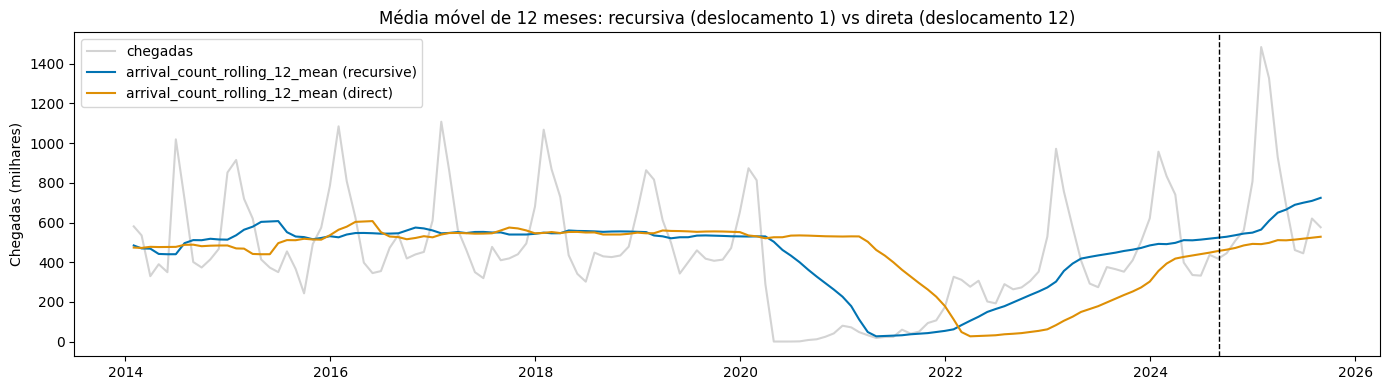

In [11]:
col = f'{TARGET}_rolling_12_mean'
fig, ax = plt.subplots(figsize=(14, 4))
view = monthly.query('date >= "2014-01-01"')
ax.plot(view['date'], view[TARGET] / 1e3, color='lightgrey', label='chegadas')
for name, frame in features.items():
    frame_view = frame.query('date >= "2014-01-01"')
    ax.plot(frame_view['date'], frame_view[col] / 1e3, label=f'{col} ({name})')
ax.axvline(TRAIN_END + pd.Timedelta(days=1), color='black', linestyle='--', linewidth=1)
ax.set_title('Média móvel de 12 meses: recursiva (deslocamento 1) vs direta (deslocamento 12)')
ax.set_ylabel('Chegadas (milhares)')
ax.legend()
plt.tight_layout()
plt.show()

## Etapa 6 — Agregações Móveis Sazonais


In [12]:
def add_seasonal_window_features(df, cfg):
    # n_shift counts seasons: shift 1 × 12 months, legal for both strategies
    return add_seasonal_rolling_features(
        df,
        seasonal_periods=[SEASONAL_PERIOD],
        rolls=SEASONAL_WINDOWS,
        column=TARGET,
        agg_funcs=SEASONAL_AGGS,
        ts_id=TS_ID,
        n_shift=1,
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['seasonal_rolling'] = (
        add_seasonal_window_features(features[name], cfg)
    )

show_step('seasonal_rolling')

# manual check: the 3-year seasonal mean of the first validation month = mean of the
# same month in the 3 previous years
by_date = features['recursive'].set_index('date')
previous_years = [VAL_START - pd.offsets.MonthEnd(12 * k) for k in (1, 2, 3)]
expected = by_date.loc[previous_years, TARGET].mean()
computed = by_date.loc[VAL_START, f'{TARGET}_12_seasonal_rolling_3_mean']
print(f'{VAL_START:%b %Y} — expected {expected:,.0f} | computed {computed:,.0f}')
assert np.isclose(expected, computed)

,n_features,features
recursive,4,"arrival_count_12_seasonal_rolling_2_mean, arri..."
direct,4,"arrival_count_12_seasonal_rolling_2_mean, arri..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_12_seasonal_rolling_2_mean,arrival_count_12_seasonal_rolling_3_mean,arrival_count_12_seasonal_rolling_2_std,arrival_count_12_seasonal_rolling_3_std
date,,,,,,
2024-06-30,train,332474.0,233605.5,163760.333333,57553.542241,127637.169478
2024-07-31,train,437103.0,332614.5,241833.000000,60858.559336,163020.625532
2024-08-31,train,417940.0,314333.5,223025.666667,71711.234214,166080.136802
2024-09-30,val,445389.0,312679.5,225344.666667,56109.630194,156384.988539
2024-10-31,val,508738.0,357784.0,269797.333333,73737.095142,161069.985203
2024-11-30,val,560732.0,428426.5,321325.333333,107435.683013,200457.458570


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_12_seasonal_rolling_2_mean,arrival_count_12_seasonal_rolling_3_mean,arrival_count_12_seasonal_rolling_2_std,arrival_count_12_seasonal_rolling_3_std
date,,,,,,
2024-06-30,train,332474.0,233605.5,163760.333333,57553.542241,127637.169478
2024-07-31,train,437103.0,332614.5,241833.000000,60858.559336,163020.625532
2024-08-31,train,417940.0,314333.5,223025.666667,71711.234214,166080.136802
2024-09-30,val,445389.0,312679.5,225344.666667,56109.630194,156384.988539
2024-10-31,val,508738.0,357784.0,269797.333333,73737.095142,161069.985203
2024-11-30,val,560732.0,428426.5,321325.333333,107435.683013,200457.458570


Sep 2024 — expected 225,345 | computed 225,345


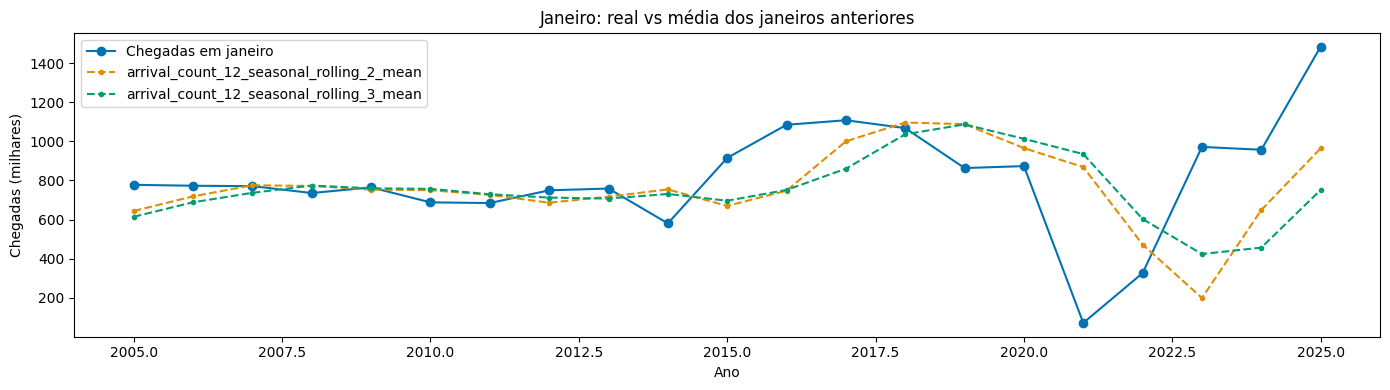

In [13]:
january = features['recursive'].query('date.dt.month == 1 and date >= "2005-01-01"')
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(
    january['date'].dt.year, january[TARGET] / 1e3, marker='o', label='Chegadas em janeiro'
)
for window in SEASONAL_WINDOWS:
    col = f'{TARGET}_12_seasonal_rolling_{window}_mean'
    ax.plot(
        january['date'].dt.year,
        january[col] / 1e3,
        marker='.',
        linestyle='--',
        label=col,
    )
ax.set_title('Janeiro: real vs média dos janeiros anteriores')
ax.set_xlabel('Ano')
ax.set_ylabel('Chegadas (milhares)')
ax.legend()
plt.tight_layout()
plt.show()

## Etapa 7 — Média Móvel Exponencialmente Ponderada (EWMA)


In [14]:
def add_ewma_features(df, cfg):
    # spans must be passed: the helper fails when only alphas are given
    return add_ewma(
        df,
        column=TARGET,
        alphas=None,
        spans=EWMA_SPANS,
        ts_id=TS_ID,
        n_shift=cfg['min_shift'],
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['ewma'] = add_ewma_features(
        features[name], cfg
    )

show_step('ewma')

,n_features,features
recursive,3,"arrival_count_ewma_span_3, arrival_count_ewma_..."
direct,3,"arrival_count_ewma_span_3, arrival_count_ewma_..."


recursive — sample around the train/validation boundary


,split,arrival_count,arrival_count_ewma_span_3,arrival_count_ewma_span_6,arrival_count_ewma_span_12
date,,,,,
2024-06-30,train,332474.0,458655.934161,532149.381254,531070.870609
2024-07-31,train,437103.0,395564.967080,475099.272324,500517.505900
2024-08-31,train,417940.0,416333.983540,464243.194517,490761.428069
2024-09-30,val,445389.0,417136.991770,451013.710369,479558.131443
2024-10-31,val,508738.0,431262.995885,449406.650264,474301.341990
2024-11-30,val,560732.0,470000.497943,466358.464474,479599.289376


direct — sample around the train/validation boundary


,split,arrival_count,arrival_count_ewma_span_3,arrival_count_ewma_span_6,arrival_count_ewma_span_12
date,,,,,
2024-06-30,train,332474.0,342843.160791,413463.392736,412916.322819
2024-07-31,train,437103.0,359245.580396,402658.994811,407182.734693
2024-08-31,train,417940.0,362143.290198,391910.996294,400699.390894
2024-09-30,val,445389.0,357249.145099,380609.283067,393261.792295
2024-10-31,val,508738.0,383586.572549,388984.916476,395825.208865
2024-11-30,val,560732.0,443990.786275,421959.226055,412528.253655


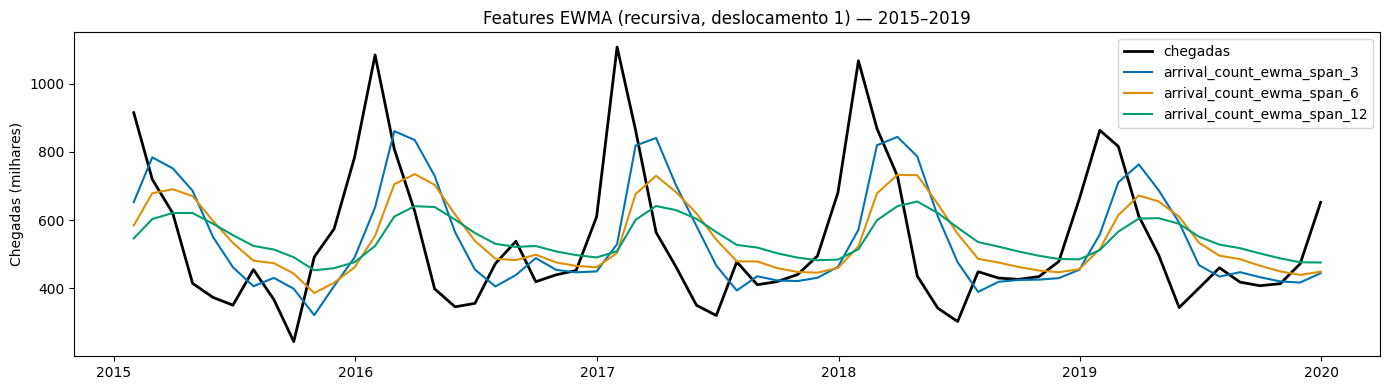

In [15]:
view = features['recursive'].query('"2015-01-01" <= date < "2020-01-01"')
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(view['date'], view[TARGET] / 1e3, color='black', linewidth=2, label='chegadas')
for span in EWMA_SPANS:
    col = f'{TARGET}_ewma_span_{span}'
    ax.plot(view['date'], view[col] / 1e3, label=col)
ax.set_title('Features EWMA (recursiva, deslocamento 1) — 2015–2019')
ax.set_ylabel('Chegadas (milhares)')
ax.legend()
plt.tight_layout()
plt.show()

## Etapa 8 — Features de Calendário e Tempo Decorrido


In [16]:
# month-end dates never start a quarter or a year → the helper's flags are constant
CONSTANT_ON_MONTH_END = ['cal_Is_quarter_start', 'cal_Is_year_start']


def add_calendar_features(df, cfg):
    df, added = add_temporal_features(
        df,
        field_name='date',
        frequency=FREQ,
        add_elapsed=True,
        prefix='cal',
        drop=False,
    )
    assert all((df[c] == df[c].iloc[0]).all() for c in CONSTANT_ON_MONTH_END)
    df = df.drop(columns=CONSTANT_ON_MONTH_END)
    added = [c for c in added if c not in CONSTANT_ON_MONTH_END]
    flag_cols = [c for c in added if c.startswith('cal_Is_')]
    df[flag_cols] = df[flag_cols].astype(int)
    df['cal_Elapsed'] = df['cal_Elapsed'].astype('int64')
    return df, added


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['calendar'] = add_calendar_features(
        features[name].copy(), cfg
    )

show_step('calendar')

,n_features,features
recursive,5,"cal_Month, cal_Quarter, cal_Is_quarter_end, ca..."
direct,5,"cal_Month, cal_Quarter, cal_Is_quarter_end, ca..."


recursive — sample around the train/validation boundary


,split,arrival_count,cal_Month,cal_Quarter,cal_Is_quarter_end,cal_Is_year_end,cal_Elapsed
date,,,,,,,
2024-06-30,train,332474.0,6,2,1,0,1719705600
2024-07-31,train,437103.0,7,3,0,0,1722384000
2024-08-31,train,417940.0,8,3,0,0,1725062400
2024-09-30,val,445389.0,9,3,1,0,1727654400
2024-10-31,val,508738.0,10,4,0,0,1730332800
2024-11-30,val,560732.0,11,4,0,0,1732924800


direct — sample around the train/validation boundary


,split,arrival_count,cal_Month,cal_Quarter,cal_Is_quarter_end,cal_Is_year_end,cal_Elapsed
date,,,,,,,
2024-06-30,train,332474.0,6,2,1,0,1719705600
2024-07-31,train,437103.0,7,3,0,0,1722384000
2024-08-31,train,417940.0,8,3,0,0,1725062400
2024-09-30,val,445389.0,9,3,1,0,1727654400
2024-10-31,val,508738.0,10,4,0,0,1730332800
2024-11-30,val,560732.0,11,4,0,0,1732924800


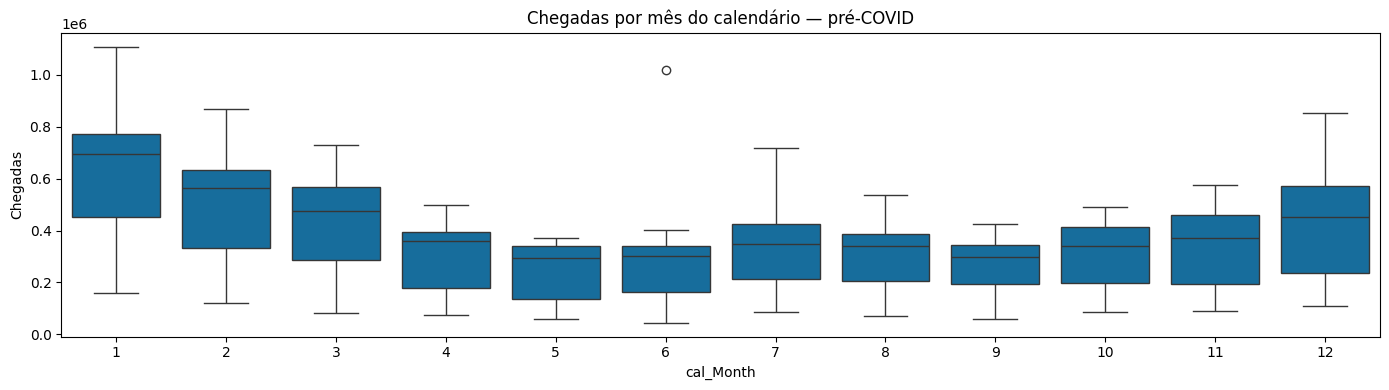

In [17]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(
    data=features['recursive'].query('date < @COVID_START'),
    x='cal_Month',
    y=TARGET,
    ax=ax,
)
ax.set_title('Chegadas por mês do calendário — pré-COVID')
ax.set_ylabel('Chegadas')
plt.tight_layout()
plt.show()

## Etapa 9 — Termos de Fourier (Sazonalidade Trigonométrica)


In [18]:
def add_fourier_month_features(df, cfg):
    # max_value must be passed: the helper raises when it has to infer it
    return add_fourier_features(
        df, column_to_encode='cal_Month', max_value=12, n_fourier_terms=FOURIER_TERMS
    )


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['fourier'] = add_fourier_month_features(
        features[name].copy(), cfg
    )

# the last 12 training months: one full cycle of the month
show_step('fourier', rows=slice(TRAIN_END - pd.offsets.MonthEnd(11), TRAIN_END))

,n_features,features
recursive,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."
direct,6,"cal_Month_sin_1, cal_Month_sin_2, cal_Month_si..."


recursive — sample around the train/validation boundary


,split,arrival_count,cal_Month_sin_1,cal_Month_sin_2,cal_Month_sin_3,cal_Month_cos_1,cal_Month_cos_2,cal_Month_cos_3
date,,,,,,,,
2023-09-30,train,352355.0,-1.000000e+00,3.673940e-16,1.000000e+00,-1.836970e-16,-1.0,5.510911e-16
2023-10-31,train,409924.0,-8.660254e-01,-8.660254e-01,2.388680e-15,5.000000e-01,-0.5,-1.000000e+00
2023-11-30,train,504395.0,-5.000000e-01,-8.660254e-01,-1.000000e+00,8.660254e-01,0.5,-2.449913e-15
2023-12-31,train,621171.0,-2.449294e-16,-4.898587e-16,-7.347881e-16,1.000000e+00,1.0,1.000000e+00
2024-01-31,train,956737.0,5.000000e-01,8.660254e-01,1.000000e+00,8.660254e-01,0.5,6.123234e-17
2024-02-29,train,833306.0,8.660254e-01,8.660254e-01,1.224647e-16,5.000000e-01,-0.5,-1.000000e+00
2024-03-31,train,740483.0,1.000000e+00,1.224647e-16,-1.000000e+00,6.123234e-17,-1.0,-1.836970e-16
2024-04-30,train,398587.0,8.660254e-01,-8.660254e-01,-2.449294e-16,-5.000000e-01,-0.5,1.000000e+00
2024-05-31,train,335652.0,5.000000e-01,-8.660254e-01,1.000000e+00,-8.660254e-01,0.5,1.194340e-15


direct — sample around the train/validation boundary


,split,arrival_count,cal_Month_sin_1,cal_Month_sin_2,cal_Month_sin_3,cal_Month_cos_1,cal_Month_cos_2,cal_Month_cos_3
date,,,,,,,,
2023-09-30,train,352355.0,-1.000000e+00,3.673940e-16,1.000000e+00,-1.836970e-16,-1.0,5.510911e-16
2023-10-31,train,409924.0,-8.660254e-01,-8.660254e-01,2.388680e-15,5.000000e-01,-0.5,-1.000000e+00
2023-11-30,train,504395.0,-5.000000e-01,-8.660254e-01,-1.000000e+00,8.660254e-01,0.5,-2.449913e-15
2023-12-31,train,621171.0,-2.449294e-16,-4.898587e-16,-7.347881e-16,1.000000e+00,1.0,1.000000e+00
2024-01-31,train,956737.0,5.000000e-01,8.660254e-01,1.000000e+00,8.660254e-01,0.5,6.123234e-17
2024-02-29,train,833306.0,8.660254e-01,8.660254e-01,1.224647e-16,5.000000e-01,-0.5,-1.000000e+00
2024-03-31,train,740483.0,1.000000e+00,1.224647e-16,-1.000000e+00,6.123234e-17,-1.0,-1.836970e-16
2024-04-30,train,398587.0,8.660254e-01,-8.660254e-01,-2.449294e-16,-5.000000e-01,-0.5,1.000000e+00
2024-05-31,train,335652.0,5.000000e-01,-8.660254e-01,1.000000e+00,-8.660254e-01,0.5,1.194340e-15


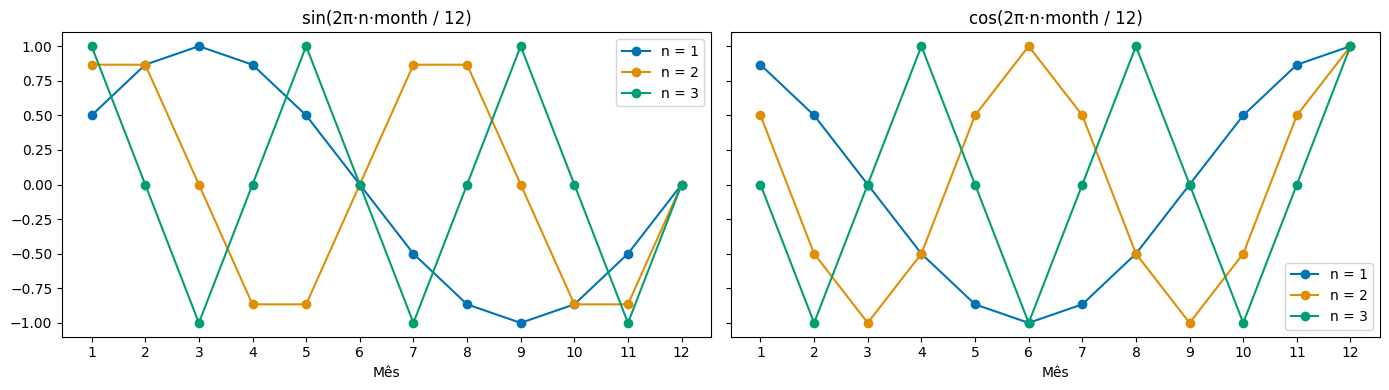

In [19]:
one_year = (
    features['recursive']
    .set_index('date')
    .loc[TRAIN_END - pd.offsets.MonthEnd(11) : TRAIN_END]
    .set_index('cal_Month')
    .sort_index()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, kind in zip(axes, ['sin', 'cos']):
    for n in range(1, FOURIER_TERMS + 1):
        ax.plot(
            one_year.index,
            one_year[f'cal_Month_{kind}_{n}'],
            marker='o',
            label=f'n = {n}',
        )
    ax.set_title(f'{kind}(2π·n·month / 12)')
    ax.set_xticks(range(1, 13))
    ax.set_xlabel('Mês')
    ax.legend()
plt.tight_layout()
plt.show()

## Etapa 10 — Features de Domínio (Específicas do Projeto)

Marcadores de regime da COVID-19 para identificar meses de colapso pandêmico e meses em que os lags apontam para o período pandêmico.


In [20]:
def add_domain_features(df, cfg):
    df = df.copy()
    df['is_covid'] = df['date'].between(COVID_START, COVID_END).astype(int)
    df['is_covid_recovery'] = (
        df['date'].between(POST_COVID_START, COVID_RECOVERY_END).astype(int)
    )
    df['days_in_month'] = df['date'].dt.days_in_month
    added = ['is_covid', 'is_covid_recovery', 'days_in_month']

    # flag the lag positions that point into the pandemic (no COVID before 1989)
    df, covid_lags = add_lags(df, lags=cfg['lags'], column='is_covid', ts_id=TS_ID)
    df[covid_lags] = df[covid_lags].fillna(0).astype(int)
    return df, added + covid_lags


for name, cfg in STRATEGIES.items():
    features[name], feature_groups[name]['domain'] = add_domain_features(
        features[name], cfg
    )

show_step('domain', rows=slice('2021-11-30', '2022-03-31'))

,n_features,features
recursive,9,"is_covid, is_covid_recovery, days_in_month, is..."
direct,7,"is_covid, is_covid_recovery, days_in_month, is..."


recursive — sample around the train/validation boundary


,split,arrival_count,is_covid,is_covid_recovery,days_in_month,is_covid_lag_1,is_covid_lag_2,is_covid_lag_12,is_covid_lag_13,is_covid_lag_24,is_covid_lag_36
date,,,,,,,,,,,
2021-11-30,train,107123.0,1,0,30,1,1,1,1,0,0
2021-12-31,train,174834.0,1,0,31,1,1,1,1,0,0
2022-01-31,train,326670.0,0,1,31,1,1,1,1,0,0
2022-02-28,train,311342.0,0,1,28,0,1,1,1,0,0
2022-03-31,train,276708.0,0,1,31,0,0,1,1,0,0


direct — sample around the train/validation boundary


,split,arrival_count,is_covid,is_covid_recovery,days_in_month,is_covid_lag_12,is_covid_lag_13,is_covid_lag_24,is_covid_lag_36
date,,,,,,,,,
2021-11-30,train,107123.0,1,0,30,1,1,0,0
2021-12-31,train,174834.0,1,0,31,1,1,0,0
2022-01-31,train,326670.0,0,1,31,1,1,0,0
2022-02-28,train,311342.0,0,1,28,1,1,0,0
2022-03-31,train,276708.0,0,1,31,1,1,0,0


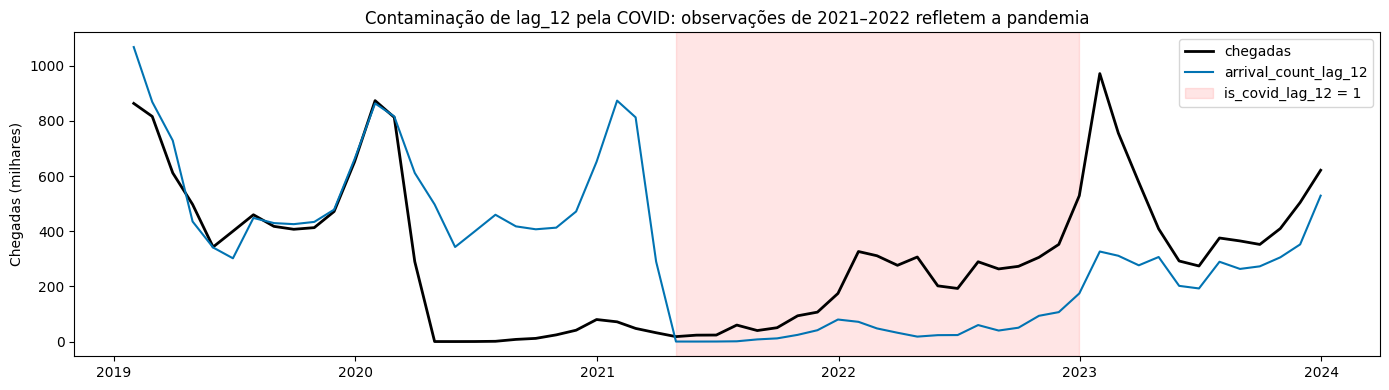

In [21]:
frame = features['recursive']
fig, ax = plt.subplots(figsize=(14, 4))
view = frame.query('"2019-01-01" <= date < "2024-01-01"')
ax.plot(view['date'], view[TARGET] / 1e3, color='black', linewidth=2, label='chegadas')
ax.plot(view['date'], view[f'{TARGET}_lag_12'] / 1e3, label=f'{TARGET}_lag_12')
contaminated = view.loc[view['is_covid_lag_12'] == 1, 'date']
ax.axvspan(
    contaminated.min(),
    contaminated.max(),
    color='red',
    alpha=0.1,
    label='is_covid_lag_12 = 1',
)
ax.set_title('Contaminação de lag_12 pela COVID: observações de 2021–2022 refletem a pandemia')
ax.set_ylabel('Chegadas (milhares)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretação.** De abril de 2021 a dezembro de 2022, `lag_12` contém valores do período pandêmico.


## Etapa 11 — O Pipeline de Features


In [22]:
FEATURE_STEPS = [
    ('lags', add_lag_features),
    ('rolling', add_rolling_window_features),
    ('seasonal_rolling', add_seasonal_window_features),
    ('ewma', add_ewma_features),
    ('calendar', add_calendar_features),
    ('fourier', add_fourier_month_features),
    ('domain', add_domain_features),
]
TARGET_DERIVED_GROUPS = ['lags', 'rolling', 'seasonal_rolling', 'ewma']


def build_feature_matrix(monthly_df, strategy):
    """Apply every feature step to a copy of the monthly series for one strategy."""
    cfg = STRATEGIES[strategy]
    df = monthly_df.copy()
    groups = {}
    for group, step in FEATURE_STEPS:
        df, groups[group] = step(df, cfg)
    return df, groups


for name in STRATEGIES:
    rebuilt, groups = build_feature_matrix(monthly, name)
    pd.testing.assert_frame_equal(rebuilt, features[name])
    assert groups == feature_groups[name]
    print(
        f'{name:<9}: pipeline reproduces the step-by-step table '
        f'({rebuilt.shape[1]} columns)'
    )

display(
    pd.DataFrame({
        name: {group: len(cols) for group, cols in groups.items()}
        for name, groups in feature_groups.items()
    }).assign(**{'target-derived': lambda d: d.index.isin(TARGET_DERIVED_GROUPS)})
)

recursive: pipeline reproduces the step-by-step table (49 columns)
direct   : pipeline reproduces the step-by-step table (45 columns)


,recursive,direct,target-derived
lags,6,4,True
rolling,12,12,True
seasonal_rolling,4,4,True
ewma,3,3,True
calendar,5,5,False
fourier,6,6,False
domain,9,7,False


## Etapa 12 — Verificação de Não-Vazamento (Leakage Check)


In [23]:
def target_derived_columns(groups):
    return [col for group in TARGET_DERIVED_GROUPS for col in groups[group]]


def check_no_leakage(strategy, cutoff):
    min_shift = STRATEGIES[strategy]['min_shift']
    base, groups = build_feature_matrix(monthly, strategy)
    perturbed = monthly.copy()
    perturbed.loc[perturbed['date'] > cutoff, TARGET] *= 10
    shocked, _ = build_feature_matrix(perturbed, strategy)

    cols = target_derived_columns(groups)
    last_safe = cutoff + pd.offsets.MonthEnd(min_shift)
    safe = base['date'] <= last_safe
    first_unsafe = base['date'] == last_safe + pd.offsets.MonthEnd(1)
    unchanged = np.allclose(
        base.loc[safe, cols], shocked.loc[safe, cols], equal_nan=True
    )
    # control is not applicable when the next row is beyond the data
    detects = (
        not np.allclose(
            base.loc[first_unsafe, cols],
            shocked.loc[first_unsafe, cols],
            equal_nan=True,
        )
        if first_unsafe.any()
        else None
    )
    return {
        'strategy': strategy,
        'cutoff': f'{cutoff:%b %Y}',
        'rows that must not change': f'up to {last_safe:%b %Y}',
        'unchanged (no leakage)': unchanged,
        'next row changes (control)': detects,
    }


leakage = pd.DataFrame([
    check_no_leakage(strategy, cutoff)
    for strategy in STRATEGIES
    for cutoff in [pd.Timestamp('2015-06-30'), TRAIN_END]
])
display(leakage)
assert leakage['unchanged (no leakage)'].all()
assert leakage['next row changes (control)'].dropna().all()

,strategy,cutoff,rows that must not change,unchanged (no leakage),next row changes (control)
0,recursive,Jun 2015,up to Jul 2015,True,True
1,recursive,Aug 2024,up to Sep 2024,True,True
2,direct,Jun 2015,up to Jun 2016,True,True
3,direct,Aug 2024,up to Aug 2025,True,None


## Etapa 13 — Linhas de Warm-up e Mascaramento das Linhas de Validação


In [24]:
model_ready = {}
for name, frame in features.items():
    cols = target_derived_columns(feature_groups[name])
    complete = frame[cols].notna().all(axis=1)
    first_complete = frame.loc[complete, 'date'].min()
    ready = frame[frame['date'] >= first_complete].reset_index(drop=True)
    train_nans = int(ready.loc[ready['split'] == 'train', cols].isna().sum().sum())
    if name == 'recursive':
        ready.loc[ready['split'] == 'val', cols] = np.nan
    model_ready[name] = ready
    print(
        f'{name:<9}: first complete row {first_complete:%b %Y} | '
        f'dropped {len(frame) - len(ready)} warm-up rows | '
        f'{ready.query("split == 'train'").shape[0]} train + '
        f'{ready.query("split == 'val'").shape[0]} validation rows | '
        f'NaNs left in train: {train_nans}'
    )

recursive: first complete row Jan 1992 | dropped 36 warm-up rows | 392 train + 12 validation rows | NaNs left in train: 0
direct   : first complete row Jan 1992 | dropped 36 warm-up rows | 392 train + 12 validation rows | NaNs left in train: 0


## Etapa 14 — Visão Geral das Features


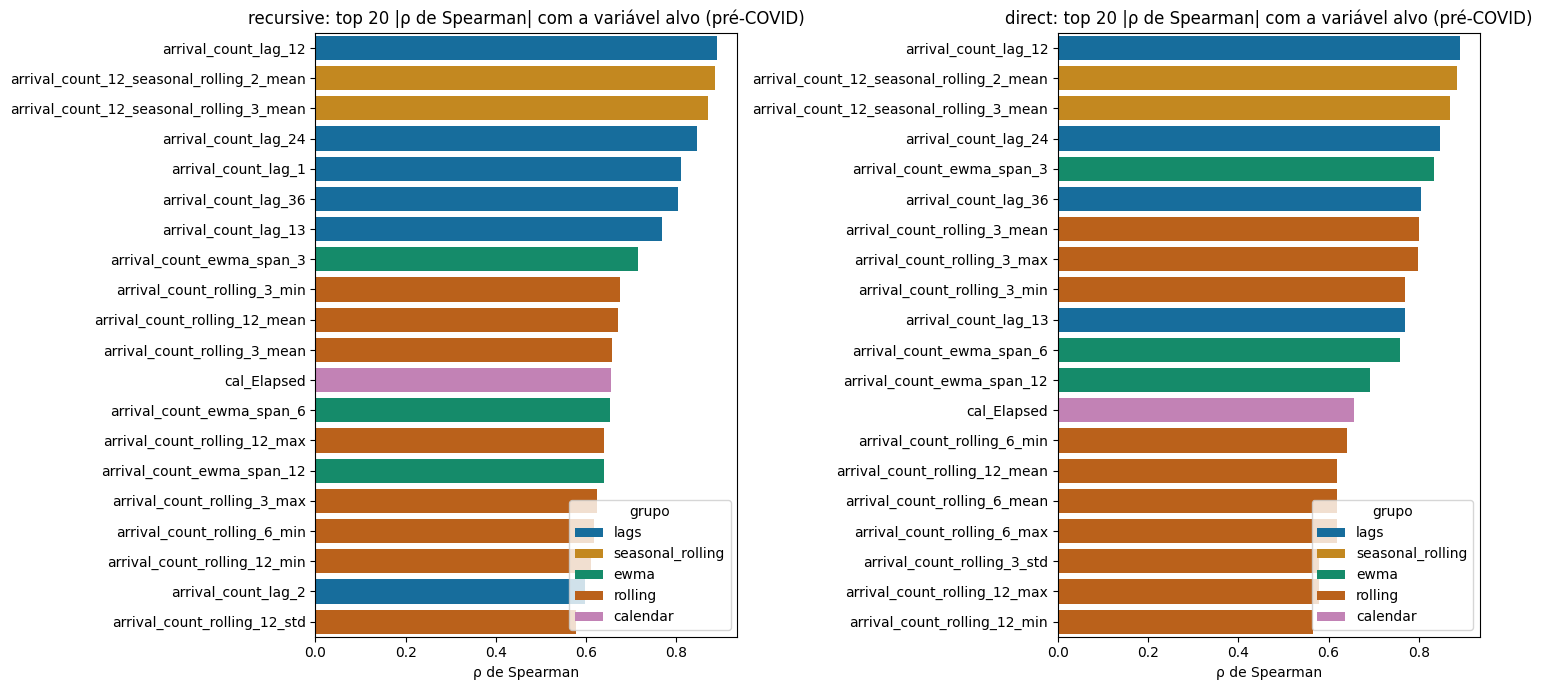

In [25]:
def feature_columns(groups):
    return [col for cols in groups.values() for col in cols]


TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, (name, frame) in zip(axes, model_ready.items()):
    pre = frame.query('split == "train" and date < @COVID_START')
    cols = [
        c
        for c in feature_columns(feature_groups[name])
        if not (pre[c] == pre[c].iloc[0]).all()
    ]
    corr = pre[cols].corrwith(pre[TARGET], method='spearman')
    top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(TOP_N)
    group_of = {c: g for g, cs in feature_groups[name].items() for c in cs}
    sns.barplot(
        x=top.values, y=top.index, hue=top.index.map(group_of), dodge=False, ax=ax
    )
    ax.set_title(f'{name}: top {TOP_N} |ρ de Spearman| com a variável alvo (pré-COVID)')
    ax.set_xlabel('ρ de Spearman')
    ax.set_ylabel('')
    ax.legend(title='grupo', loc='lower right')
plt.tight_layout()
plt.show()

## Etapa 15 — Salvando as Tabelas de Features

| Arquivo | Conteúdo |
|---|---|
| `features_recursive_ptbr.parquet` | Tabela recursiva: linhas de treino completas, features derivadas do alvo mascaradas (`NaN`) na validação |
| `features_direct_ptbr.parquet` | Tabela direta: completa para treino e validação |
| `feature_groups_ptbr.json` | Colunas de alvo e id, colunas de features de cada estratégia por grupo e parâmetros utilizados |


In [26]:
feature_spec = {
    'target': TARGET,
    'id_columns': ['date', TS_ID, 'split'],
    'horizon': HORIZON,
    'target_derived_groups': TARGET_DERIVED_GROUPS,
    'strategies': {
        name: {
            **STRATEGIES[name],
            'file': f'features_{name}_ptbr.parquet',
            'groups': feature_groups[name],
        }
        for name in STRATEGIES
    },
    'parameters': {
        'rolling_windows': ROLLING_WINDOWS,
        'rolling_aggs': ROLLING_AGGS,
        'seasonal_period': SEASONAL_PERIOD,
        'seasonal_windows': SEASONAL_WINDOWS,
        'seasonal_aggs': SEASONAL_AGGS,
        'ewma_spans': EWMA_SPANS,
        'fourier_terms': FOURIER_TERMS,
    },
}

for name, frame in model_ready.items():
    path = os.path.join(DATA_FOLDER_PATH, f'features_{name}_ptbr.parquet')
    frame.to_parquet(path, index=False)
    print(f'{path} → {frame.shape}')

spec_path = os.path.join(DATA_FOLDER_PATH, 'feature_groups_ptbr.json')
with open(spec_path, 'w', encoding='utf-8') as f:
    json.dump(feature_spec, f, indent=2)
print(f'{spec_path} written')


c:\git_reps\brazil_tourism_forecasting_benchmark\data\processed\features_recursive_ptbr.parquet → (404, 49)
c:\git_reps\brazil_tourism_forecasting_benchmark\data\processed\features_direct_ptbr.parquet → (404, 45)
c:\git_reps\brazil_tourism_forecasting_benchmark\data\processed\feature_groups_ptbr.json written


## Principais Conclusões (Key Takeaways)
